# Support Vector Machines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import preprocessing
from sklearn.preprocessing import label_binarize
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import mean_squared_error,confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, r2_score, RocCurveDisplay

RANDOM_STATE = 42

Support Vector Machine is a class of models that can take almost any shape (including linear, radial, and polynomial, among others), and are generally flexible enough to be used in almost any classification endeavour  that the user chooses to undertake. There are some variations of the methods: 

- Maximal Margin Classifier: a model for completely separable data.
- Support Vector Classifiers: a model for data that is not separable.
- Support Vector Machines: for constructing a linear or nonlinear model for data that may or may not be separable. 


### Example 

Creating hyperplanes in two dimensions.

(a) Sketch the hyperplane $1 + 3X1 − X2 = 0$. Indicate the set of points for which $1+3X1 −X2 > 0$, as well as the set of points for which $1 + 3X1 − X2 < 0$.

(b) On the same plot, sketch the hyperplane $−2 + X1 + 2X2 = 0$. Indicate the set of points for which $−2 + X1 + 2X2 > 0$, as well as the set of points for which $−2 + X1 + 2X2 < 0$.

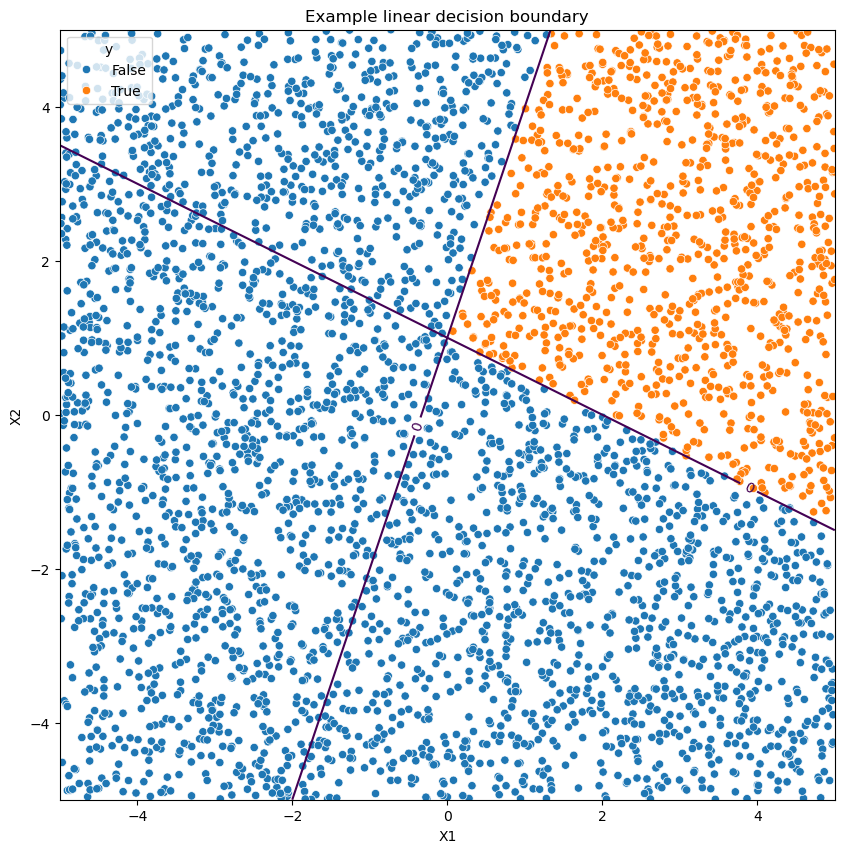

In [2]:
# Draw decision line
x1 = np.linspace(-5.0, 5.0, 100)
x2 = np.linspace(-5.0, 5.0, 100)
X1, X2 = np.meshgrid(x1,x2)
Y1 = 1 + 3*X1 -X2
Y2 = -2 + X1 + 2*X2

# Gen samples
x1 = np.random.uniform(-1, 1, 4000) * 5
x2 = np.random.uniform(-1, 1, 4000) * 5
y1 = ((1 + 3*x1 - x2) > 0)*1
y2 = ((-2 + x1 + 2*x2) > 0)*1
y = np.all([y1, y2], axis=0)

df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})

# Plot data
fig, ax = plt.subplots(figsize=(10,10))
CS1 = ax.contour(X1,X2,Y1, [0])
ax.clabel(CS1, inline=1, fontsize=10)
CS2 = ax.contour(X1,X2,Y2, [0])
ax.clabel(CS2, inline=1, fontsize=10)
sns.scatterplot(x='x1', y='x2', hue='y', data=df)
plt.xlabel('X1')
plt.ylabel('X2')
ax.set_title('Example linear decision boundary');

### Example

We have seen that in $p = 2$ dimensions, a linear decision boundary takes the form $\beta_0 + \beta_1 X1 + \beta_2 X2 = 0$. We now investigate a non-linear decision boundary.

(a) Sketch the curve

$(1 + X_1)^2 + (2 − X_2)^2 = 4$

(b) On your sketch, indicate the set of points for which 

$(1 + X_1)^2 + (2 − X_2)^2 > 4$

as well as the set of points for which 

$(1 + X_1)^2 + (2 − X_2)^2 \leq 4$

In [3]:
np.random.seed(0)

# Gen samples
x1 = np.random.uniform(-1, 1, 4000) * 5
x2 = np.random.uniform(-1, 1, 4000) * 5
y = 1*(((1+x1)**2 + (2-x2)**2) > 4)
df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
df

,x1,x2,y
0,0.488135,-2.073580,1
1,2.151894,0.665183,1
2,1.027634,-3.625856,1
3,0.448832,-1.502878,1
4,-0.763452,-4.467836,1
...,...,...,...
3995,-1.503606,4.231834,1
3996,-0.651264,4.413009,1
3997,3.300029,3.018282,1
3998,4.328062,0.391446,1


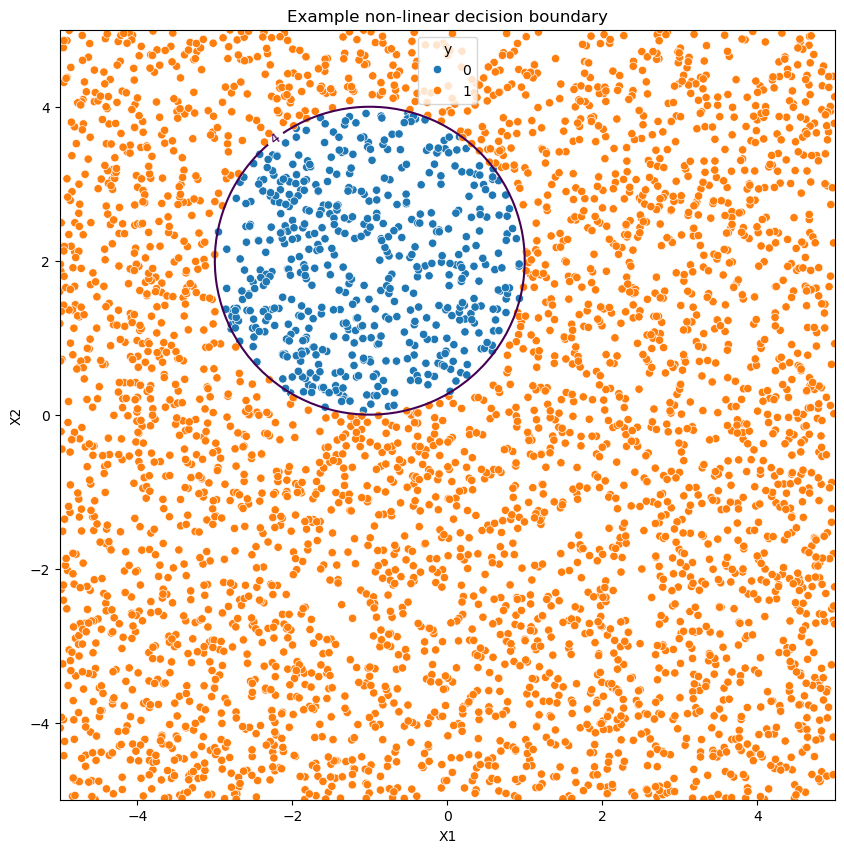

In [4]:
# Draw decision line
x1 = np.linspace(-5.0, 5.0, 100)
x2 = np.linspace(-5.0, 5.0, 100)
X1, X2 = np.meshgrid(x1,x2)
Y = (1+X1)**2 + (2-X2)**2

# Plot data
fig, ax = plt.subplots(figsize=(10,10))
CS = ax.contour(X1,X2,Y, [4])
sns.scatterplot(x='x1', y='x2', hue='y', data=df)
ax.clabel(CS, inline=1, fontsize=10)
plt.xlabel('X1')
plt.ylabel('X2')
ax.set_title('Example non-linear decision boundary');

(c) Suppose that a classifier assigns an observation to the orange class if $(1 + X_1)^2 + (2 − X_2)^2 > 4$ and to the blue class otherwise. To what class is the following observation will be classified? 

- (0, 0)?
- (−1, 1)? 
- (2, 2)? 
- (3, 8)?

**Answer**

- (0, 0)  == orange
- (−1, 1) == blue
- (2, 2)  == orange
- (3, 8)  == orange

(d) Argue that while the decision boundary in (c) is not linear in terms of $X_1$ and $X_2$, it is linear in terms of $X_1$, $X_1^2$, $X_2$, and $X_2^2$ .

The equation:

$(1 + X_1)^2 + (2 − X_2)^2 > 4$

can be expanded to:

$X_1^2 + 2X_1 + 1 + X_2^2 - 2X_2 + 4 > 4$

$5 + 2X_1- 2X_2 + X_1^2+ X_2^2 > 4$

which can be though of as a linear model of the form:

$β_0 + β_1 X_! + β_2 X_2 + β_3 X_1^2 + β_4 X_2^2 > 4$

where:

$β_0 = 5$  
$β_1 = 2$  
$β_2 = -2$  
$β_3 = 1$  
$β_4 = 1$  


#### Example

Here we explore the maximal margin classifier on a dummy data.

(a) We have $n = 7$ observations in $p = 2$ dimensions. For each observation, there is an associated class label.

(b) Sketch the optimal separating hyperplane, and provide the equation for this hyperplane.

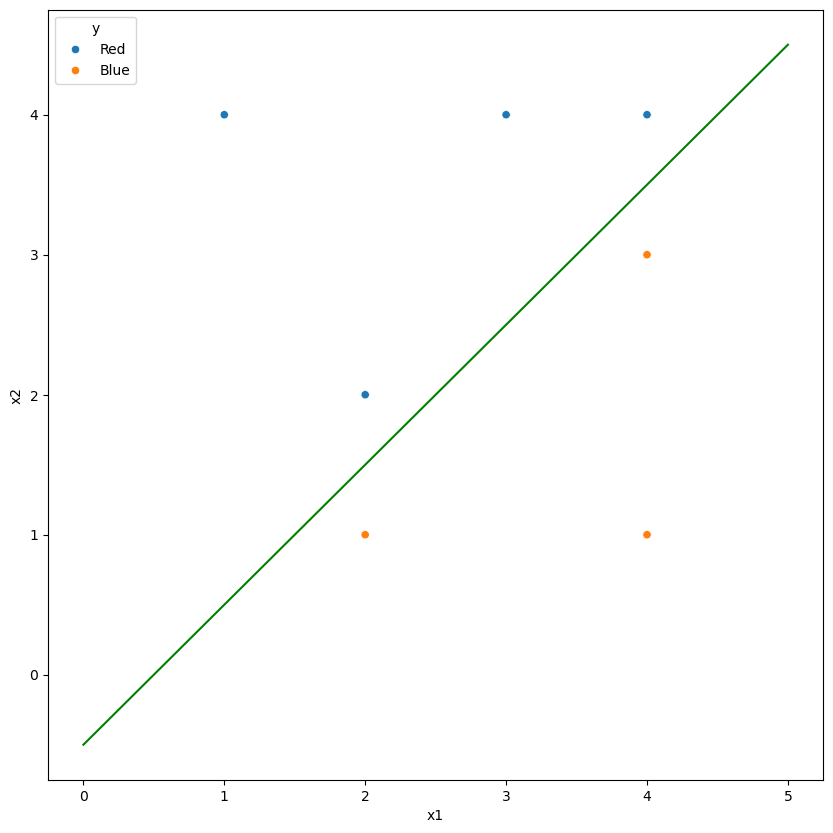

In [5]:
x1 = [3, 2, 4, 1, 2, 4, 4]
x2 = [4, 2, 4, 4, 1, 3, 1]
y = ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']

# Draw separating hyperplane
X1 = np.linspace(0, 5, 10)
X2 = X1 - 0.5

df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
plt.figure(figsize=(10,10))
ax = sns.scatterplot(x='x1', y='x2', hue='y', data=df)
ax.plot(X1, X2, color='g');

The optimal separating hyperplane is given by:  

$-0.5 + X_1 - X_2 = 0$ 

(c) Describe the classification rule for the maximal margin classifier. It should be something along the lines of “Classify to Red if $\beta_0 + \beta_1 X1 + \beta_2 X2 > 0$, and classify to Blue otherwise.”

Classify to Blue if:  

$-0.5 + X_1 - X_2 > 0$ 

and Red otherwise.

(d) On your sketch, indicate the margin for the maximal margin hyperplane.

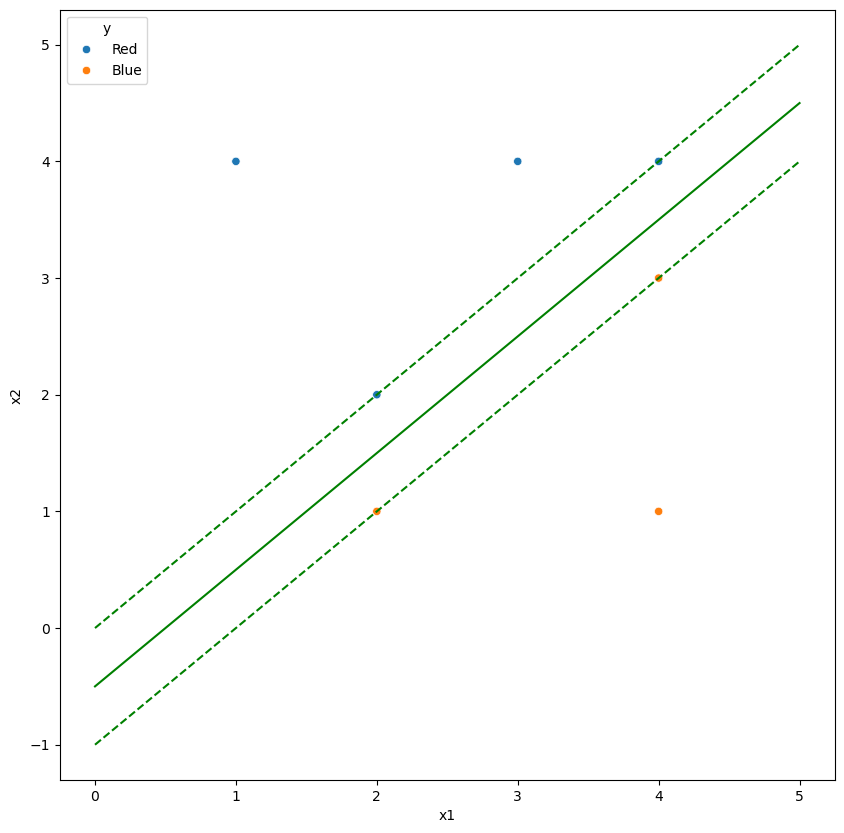

In [6]:
x1 = [3, 2, 4, 1, 2, 4, 4]
x2 = [4, 2, 4, 4, 1, 3, 1]
y = ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']

# Draw separating hyperplane
X1 = np.linspace(0, 5, 10)
X2 = X1 - 0.5

margin_upper = X1
margin_lower = X1 -1

plot_df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
plt.figure(figsize=(10,10))
ax = sns.scatterplot(x='x1', y='x2', hue='y', data=plot_df)
ax.plot(X1, X2, color='g')
ax.plot(X1, margin_upper, linestyle='--', color='g')
ax.plot(X1, margin_lower, linestyle='--', color='g');

(e) Indicate the support vectors for the maximal margin classifier.

The support vectors are those observations that lie on the dashed margins

In [7]:
class SVMClassifier:
    def __init__(self, X, y, kernel='linear', C=1, gamma='scale'):
        self.X = X
        self.y = y
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=RANDOM_STATE)
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.model = None

    def fit(self):
        self.model = SVC(kernel=self.kernel, C=self.C, gamma=self.gamma)
        self.model.fit(self.X_train, self.y_train)
        # print('Number of support vectors: ', self.model.support_.size)

    def predict(self):
        if self.model is None:
            raise Exception('SVM model not yet trained')
        return self.model.predict(self.X_test)
    
    def score(self):
        if self.model is None:
            raise Exception('SVM model not yet trained')
        training_acc = self.model.score(self.X_train, self.y_train)
        test_acc = self.model.score(self.X_test, self.y_test)
        return training_acc, test_acc

    def plot_decision_boundary(self, title='', feature_names=[]):
        if self.model is None:
            raise Exception('SVM model not yet trained')
        fig, ax = plt.subplots()
        ax.scatter(self.X.loc[:, feature_names[0]], self.X.loc[:, feature_names[1]], c=self.y, cmap='bwr', alpha=0.5)
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 500),
                             np.linspace(ylim[0], ylim[1], 500))
        Z = self.model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
                   linestyles=['--', '-', '--'])
        ax.set_title(title)
        plt.show()

    def plot_clf(self, grid_range, show_contours=False, show_support_vectors=True, feature_names=[]):
        if self.model is None:
            raise Exception('SVM model not yet trained')
        # Decision boundary plot
        # Get grid of values in given range
        x1 = grid_range
        x2 = grid_range
        xx1, xx2 = np.meshgrid(x1, x2, sparse=False)
        Xgrid = np.stack((xx1.flatten(), xx2.flatten())).T
        
        # Get decision boundary values for plot grid
        decision_boundary      = self.model.predict(Xgrid)
        decision_boundary_grid = decision_boundary.reshape(len(x2), len(x1))
        
        # Get decision function values for plot grid
        decision_function      = self.model.decision_function(Xgrid)
        decision_function_grid = decision_function.reshape(len(x2), len(x1))
        
        fig = plt.figure(figsize=(10, 10))
        if show_contours:
            plt.contourf(x1, x2, decision_function_grid);
        plt.contour(x1, x2, decision_boundary_grid);
        
        plt.scatter(self.X.loc[:, feature_names[0]], self.X.loc[:, feature_names[1]], c=self.y, cmap='bwr', alpha=0.5)
        if show_support_vectors:
            plt.scatter(self.model.support_vectors_[:,0], self.model.support_vectors_[:,1], color='red', marker='+', s=500)
        plt.show()
        print('Number of support vectors: ', self.model.support_.size)

    def tune_hyperparameters(self, param_grid, cv=5):
        if self.model is None:
            raise Exception('SVM model not yet trained')
        from sklearn.model_selection import GridSearchCV
        grid_search = GridSearchCV(self.model, param_grid, cv=cv)
        grid_search.fit(self.X, self.y)
        self.model = grid_search.best_estimator_
        print('Number of support vectors: ', self.model.support_.size)

    def plot_learning_curve(self, train_sizes=np.linspace(.1, 1.0, 5)):
        if self.model is None:
            raise Exception('SVM model not yet trained')
        train_sizes, train_scores, test_scores = learning_curve(
            self.model, self.X, self.y, train_sizes=train_sizes, cv=5, n_jobs=-1)
        train_scores_mean = np.mean(train_scores, axis=1)
        train_scores_std = np.std(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)
        test_scores_std = np.std(test_scores, axis=1)

        fig, ax = plt.subplots()
        ax.grid()
        ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                        train_scores_mean + train_scores_std, alpha=0.1,
                        color='r')
        ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                        test_scores_mean + test_scores_std, alpha=0.1,
                        color='g')
        ax.plot(train_sizes, train_scores_mean, 'o-', color='r',
                label='Training score')
        ax.plot(train_sizes, test_scores_mean, 'o-', color='g',
                label='Cross-validation score')
        ax.legend(loc='best')
        plt.show()


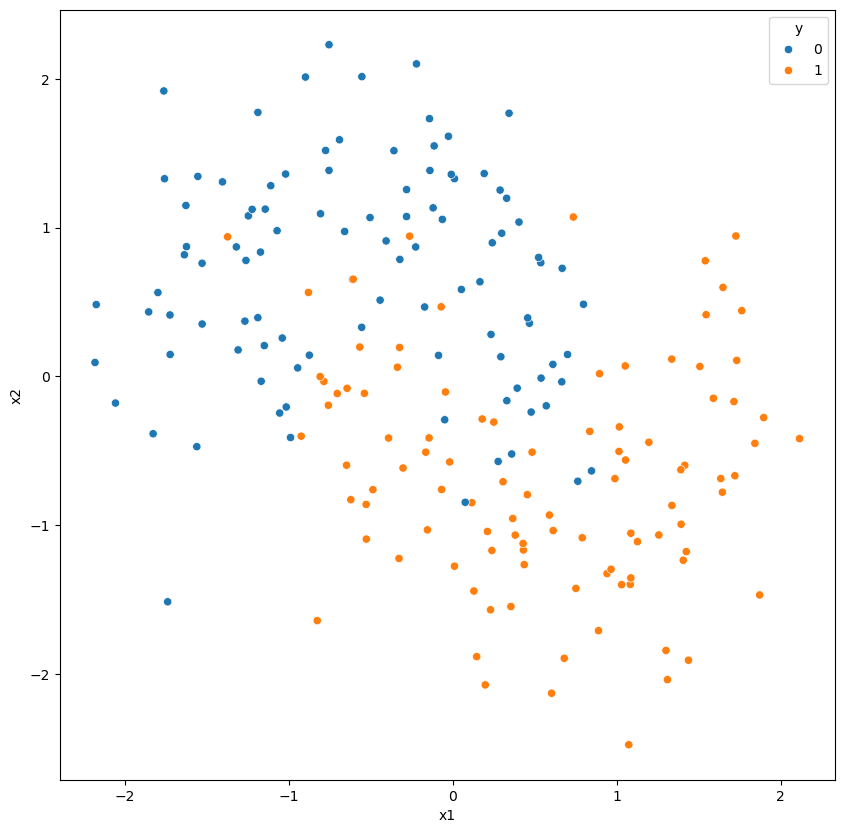

In [8]:
# Generate noisy moon shaped data
n_samples = 200
noise     = .3
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=0)

# Scale data
X = preprocessing.scale(X)

# Plot data
df = pd.concat([pd.DataFrame(data=X, columns=['x1', 'x2']), pd.Series(y, name='y')], axis=1)
plt.figure(figsize=(10, 10))
sns.scatterplot(x='x1', y='x2', hue='y', data=df);

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


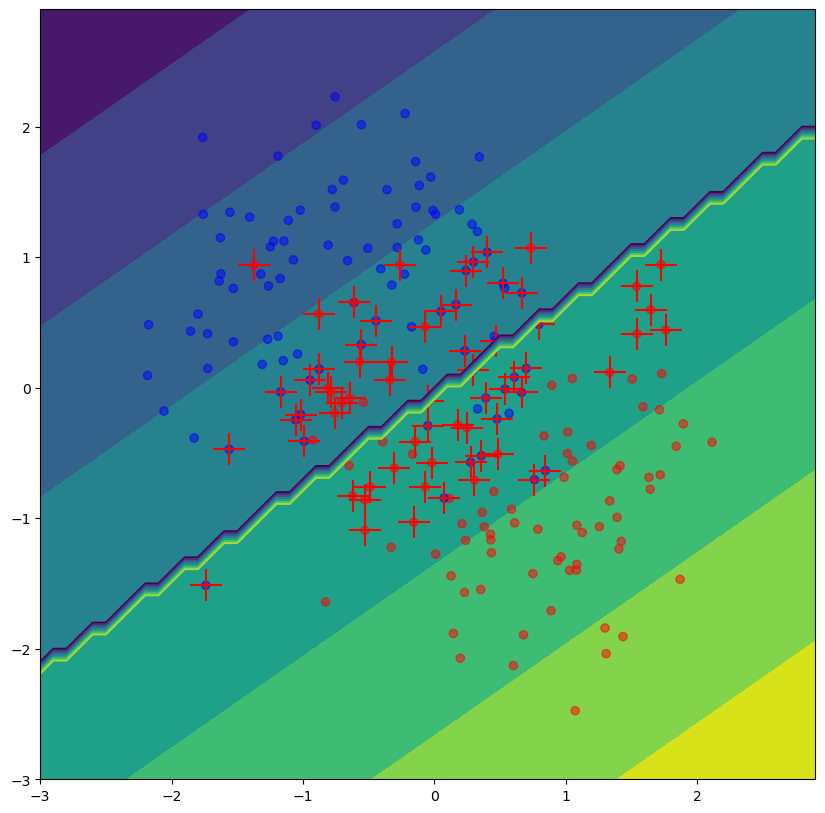

Number of support vectors:  67
Training accuracy: 0.81875
Test accuracy    : 0.9


In [9]:
X = df[["x1", "x2"]]

# Create an instance of the SVMClassifier class with default hyperparameters
svm = SVMClassifier(X,y)

# Fit the SVM model to the training data
svm.fit()

# Make predictions on the test data
y_pred = svm.predict()
y_pred

# Plot the decision boundary
svm.plot_clf(np.arange(-3, 3, .1), show_contours=True, feature_names=['x1','x2'])

training_acc, test_acc =  svm.score()
print(f'Training accuracy: {training_acc}')
print(f'Test accuracy    : {test_acc}')


/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


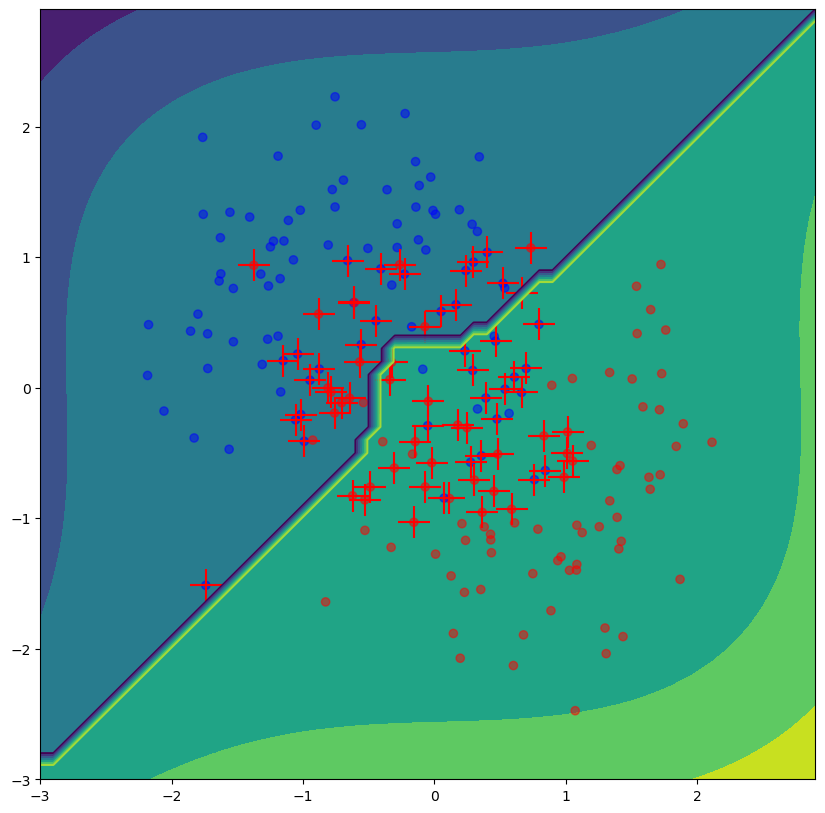

Number of support vectors:  73
Training accuracy: 0.825
Test accuracy    : 0.85


In [10]:
# Create an instance of the SVMClassifier class with default hyperparameters
svm = SVMClassifier(X,y,kernel='poly')

# Fit the SVM model to the training data
svm.fit()

# Plot the decision boundary
svm.plot_clf(np.arange(-3, 3, .1), show_contours=True, feature_names=['x1','x2'])

training_acc, test_acc =  svm.score()
print(f'Training accuracy: {training_acc}')
print(f'Test accuracy    : {test_acc}')

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


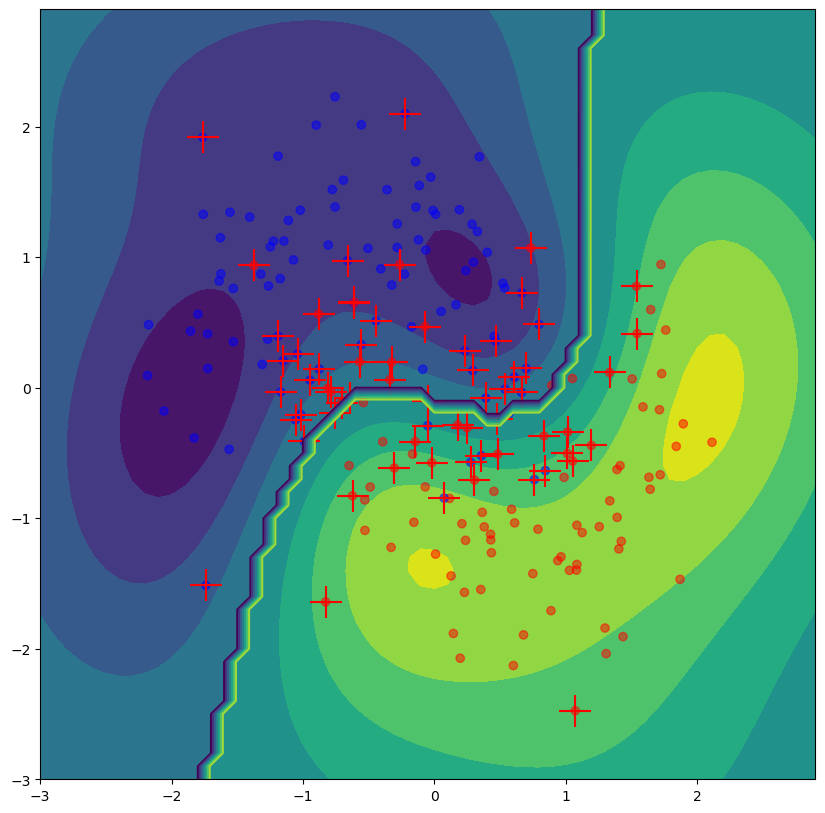

Number of support vectors:  66
Training accuracy: 0.86875
Test accuracy    : 0.975


In [11]:
# Create an instance of the SVMClassifier class with default hyperparameters
svmk = SVMClassifier(X,y,kernel='rbf')

# Fit the SVM model to the training data
svmk.fit()

# Plot the decision boundary
svmk.plot_clf(np.arange(-3, 3, .1), show_contours=True, feature_names=['x1','x2'])

training_acc, test_acc =  svmk.score()
print(f'Training accuracy: {training_acc}')
print(f'Test accuracy    : {test_acc}')

#### Loading `biopsy` data 
Feature variables in `biopsy` dataset are:

   - thick: clump thickness.
   - u.size: uniformity of cell size.
   - u.shape: uniformity of cell shape.
   - adhsn: marginal adhesion.
   - s.size: single epithelial cell size.
   - nucl: bare nuclei.
   - chrom: bland chromatin.
   - n.nuc: normal nucleoli.
   - mit: mitoses.
   - class: Class of Tumor (Benign/Malignant)

In [12]:
biopsy = sm.datasets.get_rdataset('biopsy', package='MASS',).data 
biopsy = biopsy.rename(columns={'V1':'thick','V2':"u.size", 'V3': "u.shape", 'V4': "adhsn", 
        'V5':"s.size", 'V6':"nucl", 'V7': "chrom", 'V8':"n.nuc", 'V9':"mit",  "class":"Class"})
biopsy.Class = biopsy.Class.map({"malignant": 1, "benign": 0}) 
biopsy

,ID,thick,u.size,u.shape,adhsn,s.size,nucl,chrom,n.nuc,mit,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,0
695,841769,2,1,1,1,2,1.0,1,1,1,0
696,888820,5,10,10,3,7,3.0,8,10,2,1
697,897471,4,8,6,4,3,4.0,10,6,1,1


In [13]:
Xb = biopsy[['thick', 'u.size']]
yb = biopsy['Class']
Xb

,thick,u.size
0,5,1
1,5,4
2,3,1
3,6,8
4,4,1
...,...,...
694,3,1
695,2,1
696,5,10
697,4,8


In [14]:
# Create an instance of the SVMClassifier class with default hyperparameters
svmb = SVMClassifier(Xb,yb)

# Fit the SVM model to the training data
svmb.fit()

# Make predictions on the test data
y_pred = svmb.predict()
y_pred

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0])

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


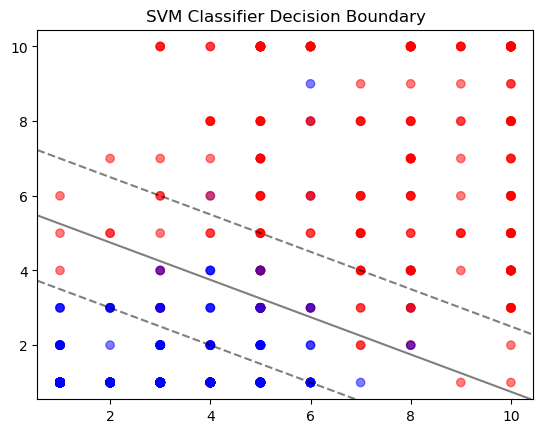

In [15]:

# Plot the decision boundary
svmb.plot_decision_boundary(title='SVM Classifier Decision Boundary', feature_names=['thick','u.size'])


/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


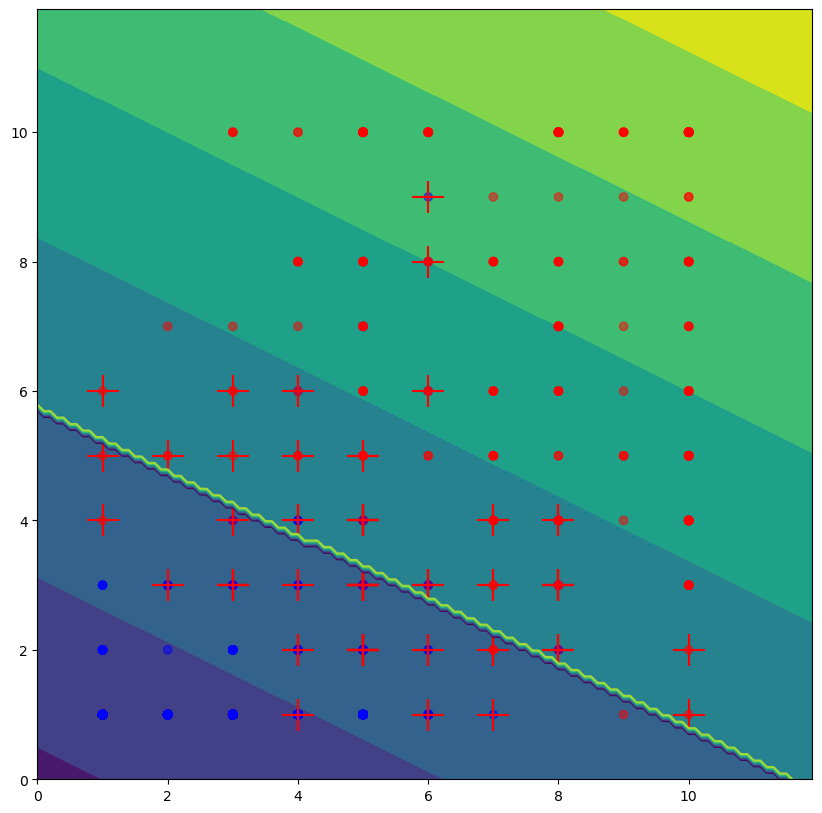

Number of support vectors:  84


In [16]:
svmb.plot_clf(np.arange(0, 12, .1), show_contours=True, feature_names=['thick','u.size'])

In [17]:
training_acc, test_acc =  svmb.score()
print(f'Training accuracy: {training_acc}')
print(f'Test accuracy    : {test_acc}')

Training accuracy: 0.9391771019677997
Test accuracy    : 0.95


In [18]:
# Tune hyperparameters using GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'gamma': ['scale', 'auto']}
svmb.tune_hyperparameters(param_grid, cv=5)

Number of support vectors:  149


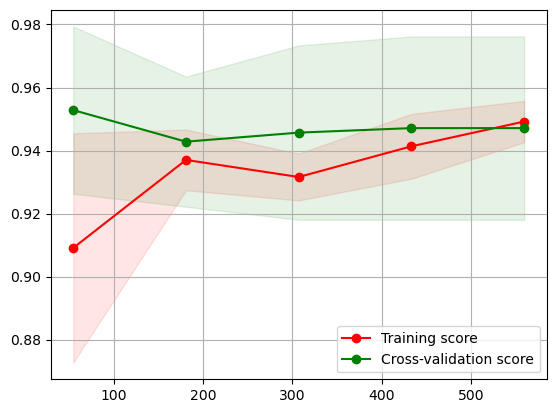

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


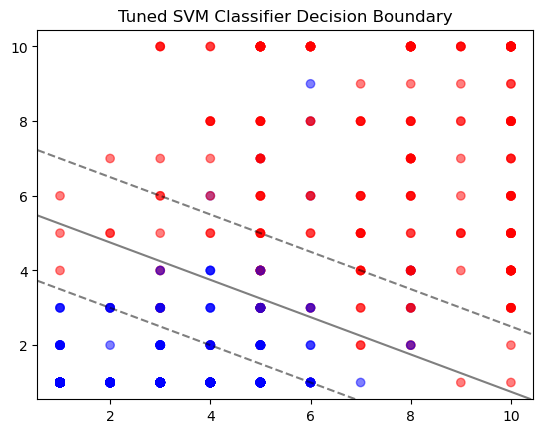

In [19]:

# Plot the learning curve
svmb.plot_learning_curve()

# Fit the tuned SVM model to the training data
svmb.fit()

# Make predictions on the test data using the tuned model
y_pred_tuned = svmb.predict()

# Plot the decision boundary of the tuned SVM model
svmb.plot_decision_boundary(title='Tuned SVM Classifier Decision Boundary',feature_names=['thick','u.size'])

In [20]:
training_acc, test_acc =  svmb.score()
print(f'Training accuracy: {training_acc}')
print(f'Test accuracy    : {test_acc}')

Training accuracy: 0.9391771019677997
Test accuracy    : 0.95


In [21]:
def compare_roc_curves(svm1, svm2):
    """
    Plots the ROC curves of two SVMClassifier models
    """
    fig, ax = plt.subplots()
    RocCurveDisplay.from_estimator(svm1.model, svm1.X_test, svm1.y_test, ax=ax, name='SVM 1')
    RocCurveDisplay.from_estimator(svm2.model, svm2.X_test, svm2.y_test, ax=ax, name='SVM 2')
    ax.set_title('ROC Curves of SVM Classifiers')
    plt.show()


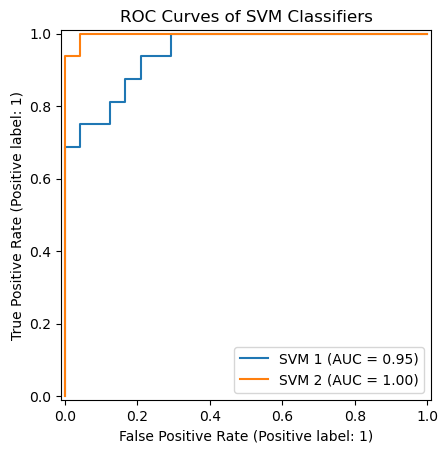

In [22]:
compare_roc_curves(svm,svmk)